# 1. Линейная алгебра

In [ ]:
!pip install numpy sympy matplotlib

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve, Matrix, simplify, diff

## Задание 1:


$$
A = \begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix},
\quad
B = \begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix},
\quad
C = \begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}.
$$

Посчитайте матрицу $D = A^T C - 2 A^T B^T$.

In [33]:
# Задаём исходные матрицы
A = np.array([[2, -4],
              [3,  5],
              [-1, 0]])

B = np.array([[1,  2, 7],
              [-3, -4, 0],
              [5,  2, 1]])

C = np.array([[6, -3, 9],
              [4, -5, 2],
              [8,  1, 5]])

# Шаг 1. Транспонируем матрицы A и B
A_T = A.T     # Aᵀ (размер: 2×3)
B_T = B.T     # Bᵀ (размер: 3×3)

print("1. Транспонированные матрицы:")
print("Aᵀ =\n", A_T)
print("\nBᵀ =\n", B_T)

# Шаг 2. Вычисляем AᵀC (умножение Aᵀ на C)
# Aᵀ: 2×3, C: 3×3 → результат: 2×3
A_T_C = np.dot(A_T, C)  # или A_T @ C
print("\n2. AᵀC =\n", A_T_C)

# Шаг 3. Вычисляем AᵀBᵀ (умножение Aᵀ на Bᵀ)
# Aᵀ: 2×3, Bᵀ: 3×3 → результат: 2×3
A_T_B_T = np.dot(A_T, B_T)  # или A_T @ B_T
print("\n3. AᵀBᵀ =\n", A_T_B_T)

# Шаг 4. Умножаем AᵀBᵀ на 2
two_A_T_B_T = 2 * A_T_B_T
print("\n4. 2AᵀBᵀ =\n", two_A_T_B_T)

# Шаг 5. Вычисляем итоговую матрицу D = AᵀC − 2AᵀBᵀ
D = A_T_C - two_A_T_B_T
print("\n5. Итоговая матрица D = AᵀC − 2AᵀBᵀ =\n", D)

# Дополнительно: выводим размер итоговой матрицы
print(f"\nРазмер матрицы D: {D.shape}")

1. Транспонированные матрицы:
Aᵀ =
 [[ 2  3 -1]
 [-4  5  0]]

Bᵀ =
 [[ 1 -3  5]
 [ 2 -4  2]
 [ 7  0  1]]

2. AᵀC =
 [[ 16 -22  19]
 [ -4 -13 -26]]

3. AᵀBᵀ =
 [[  1 -18  15]
 [  6  -8 -10]]

4. 2AᵀBᵀ =
 [[  2 -36  30]
 [ 12 -16 -20]]

5. Итоговая матрица D = AᵀC − 2AᵀBᵀ =
 [[ 14  14 -11]
 [-16   3  -6]]

Размер матрицы D: (2, 3)


## Задание 2:

Дано выражение:
$$
3 \cdot
\begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+ 2 \cdot
\begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
=
\begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}.
$$

Найдите значения x, y, z и v, при которых выражение верно.


In [24]:
# Объявляем символьные переменные
x, y, z, v = symbols('x y z v')


# Задаём матрицы
M1 = Matrix([[x,  2,  3],
            [-1, y,  4]])

M2 = Matrix([[1,   2, -5],
            [2,  -6,  z]])


RHS = Matrix([[8,  v, -1],
            [1,  6,  4]])

# Формируем левую часть: 3·M1 + 2·M2
LHS = 3 * M1 + 2 * M2

# Создаём систему уравнений: LHS[i,j] == RHS[i,j] для всех элементов
# Система уравнений
equations = [Eq(LHS[i, j], RHS[i, j]) for i in range(2) for j in range(3)]

# Решаем систему уравнений
solution = solve(equations, (x, y, z, v))

# Выводим результат
print("Решение:", solution)


# Дополнительно: подставляем найденные значения и проверяем равенство
print("\nПроверка (подстановка решений):")
M1_solved = M1.subs(solution)
M2_solved = M2.subs(solution)
RHS_solved = RHS.subs(solution)
LHS_final = 3 * M1_solved + 2 * M2_solved

print("Левая часть (3·M1 + 2·M2):")
display(LHS_final)
print("Правая часть (RHS):")
display(RHS_solved)
print("Равенство выполняется:", LHS_final == RHS_solved)


Решение: {v: 10, x: 2, y: 6, z: -4}

Проверка (подстановка решений):
Левая часть (3·M1 + 2·M2):


Matrix([
[8, 10, -1],
[1,  6,  4]])

Правая часть (RHS):


Matrix([
[8, 10, -1],
[1,  6,  4]])

Равенство выполняется: True


## Задание 3:

Найдите такие значения параметров $p$ и $q$, при которых ранг матрицы  
$$
A = \begin{pmatrix}
1 & 2 & 3 \\
3 & 6 & p \\
5 & 10 & q
\end{pmatrix}
$$  
равен единице.


In [18]:
from sympy import symbols, Matrix, Eq, solve, simplify
import numpy as np

# Определяем символы
p, q = symbols('p q')

# Исходная матрица
A = Matrix([
    [1, 2, 3],
    [3, 6, p],
    [5, 10, q]
])

print("Исходная матрица A:")
display(A)

# Копируем для преобразований
B = A.copy()
n_rows, n_cols = B.shape

print("\nПошаговые преобразования (метод Гаусса с перестановкой):")

# Основной цикл по столбцам (ведущие элементы)
for k in range(n_rows):
    print(f"\nШаг {k+1}: обработка столбца {k}")
    
    # Проверяем ведущий элемент
    if B[k, k] == 0:
        print(f"  Ведущий элемент B[{k},{k}] = 0. Ищем ненулевой элемент ниже...")
        
        # Ищем первую строку ниже k с ненулевым элементом в столбце k
        swap_row = None
        for i in range(k + 1, n_rows):
            if B[i, k] != 0:
                swap_row = i
                break
        
        if swap_row is None:
            print(f"  Не найдено ненулевых элементов в столбце {k} ниже строки {k}. Пропускаем.")
            continue
        
        # Переставляем строки
        print(f"  Переставляем строки {k} и {swap_row}")
        B[k, :], B[swap_row, :] = B[swap_row, :], B[k, :]
        print("  Матрица после перестановки:")
        print(B)
    
    # Теперь ведущий элемент гарантированно не ноль
    print(f"  Ведущий элемент: B[{k},{k}] = {B[k,k]}")
    
    # Обнуляем строки ниже k
    for i in range(k + 1, n_rows):
        m = B[i, k] / B[k, k]
        print(f"  Строка {i} = Строка {i} - ({m}) × Строка {k}")
        B[i, :] = B[i, :] - m * B[k, :]
    
    print("  Текущая матрица:")
    display(B)

print("\nИтоговая ступенчатая матрица:")
display(B)

# --- Извлекаем условия для ранга = 1 ---
equations = []
for i in range(1, n_rows):  # проверяем строки со 2-й по последнюю
    for j in range(n_cols):
        if B[i, j] != 0 and B[i, j].has(p, q):  # элемент зависит от p/q и не ноль
            equations.append(Eq(B[i, j], 0))


print(f"\nПолучены уравнения для параметров:")
for eq in equations:
    display(eq)

# Решаем систему
solution = solve(equations, (p, q))
if solution:
    p_sol, q_sol = solution[p], solution[q]
    print(f"\nНайденные значения параметров:")
    print(f"p = {p_sol}")
    print(f"q = {q_sol}")
else:
    print("\nНе удалось найти решение.")
    exit()

# --- Проверка ранга ---
def matrix_rank_numeric(mat):
    return np.linalg.matrix_rank(np.array(mat).astype(float))

A_solved = A.subs({p: p_sol, q: q_sol})
rank = matrix_rank_numeric(A_solved)

print(f"\nМатрица при p = {p_sol}, q = {q_sol}:")
display(A_solved)
print(f"Ранг матрицы: {rank}")


if rank == 1:
    print("✅ Вывод: ранг равен 1 при найденных параметрах.")
else:
    print("❌ Вывод: ранг не равен 1.")


Исходная матрица A:


Matrix([
[1,  2, 3],
[3,  6, p],
[5, 10, q]])


Пошаговые преобразования (метод Гаусса с перестановкой):

Шаг 1: обработка столбца 0
  Ведущий элемент: B[0,0] = 1
  Строка 1 = Строка 1 - (3) × Строка 0
  Строка 2 = Строка 2 - (5) × Строка 0
  Текущая матрица:


Matrix([
[1, 2,      3],
[0, 0,  p - 9],
[0, 0, q - 15]])


Шаг 2: обработка столбца 1
  Ведущий элемент B[1,1] = 0. Ищем ненулевой элемент ниже...
  Не найдено ненулевых элементов в столбце 1 ниже строки 1. Пропускаем.

Шаг 3: обработка столбца 2
  Ведущий элемент: B[2,2] = q - 15
  Текущая матрица:


...

Eq(p - 9, 0)

Eq(q - 15, 0)


Найденные значения параметров:
p = 9
q = 15

Матрица при p = 9, q = 15:


Matrix([
[1,  2,  3],
[3,  6,  9],
[5, 10, 15]])

Ранг матрицы: 1
✅ Вывод: ранг равен 1 при найденных параметрах.


## Задание 4:


Относительно канонического (стандартного) базиса в $\mathbb{R}^2$ даны три вектора:
- $\mathbf{a}_1 = (2,\ -5)^\top$,
- $\mathbf{a}_2 = (-1,\ 3)^\top$,
- $\mathbf{x} = (1,\ -4)^\top$.

Примите векторы $\mathbf{a}_1$, $\mathbf{a}_2$ за новый базис $B$, предварительно проверив, что они линейно независимы.

#### Задания

**(a)** Найдите координаты $[\mathbf{x}]_B$ вектора $\mathbf{x}$ в новом базисе.

**(b)** Предположим, что координаты вектора $\mathbf{y}$ в базисе $B$ заданы: $[\mathbf{y}]_B = (1,\ 1)^\top$. Найдите координаты вектора $\mathbf{y}$ в стандартном базисе.

### Решение:
#### Проверка линейной независимости векторов **a₁**, **a₂** и обратимости  полученной из них матрицы:

Даны векторы:
- **a₁** = (2, −5)ᵀ
- **a₂** = (−1, 3)ᵀ

**Шаг 1.** Составляем матрицу $A$ из векторов-столбцов:
$$
A = \begin{pmatrix} 2 & -1 \\ -5 & 3 \end{pmatrix}
$$

**Шаг 2.** Вычисляем определитель:
$$
\det(A) = 2 \cdot 3 - (-1) \cdot (-5) = 6 - 5 = 1
$$

**Шаг 3.** Вывод:  
Поскольку $\det(A) = 1 \neq 0$, → матрица A обратима и векторы **a₁** и **a₂** линейно независимы и образуют базис $B$ в $\mathbb{R}^2$.

---

### (a) Нахождение координат **[x]ₐ** вектора **x** в базисе $B$:

Дано: **x** = (1, −4)ᵀ.

**Шаг 1.** Записываем уравнение разложения:
$$
x = c_1 \cdot a_1 + c_2 \cdot a_2
$$
В координатной форме:
$$
\begin{pmatrix} 1 \\ -4 \end{pmatrix} = c_1 \begin{pmatrix} 2 \\ -5 \end{pmatrix} + c_2 \begin{pmatrix} -1 \\ 3 \end{pmatrix}
$$

**Шаг 2.** Составляем систему уравнений:
$$
\begin{cases}
2c_1 - c_2 = 1 \\
-5c_1 + 3c_2 = -4
\end{cases}
$$

**Шаг 3.** Решаем матричным методом. Находим $A^{-1}$:
$$
A^{-1} = \frac{1}{\det(A)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix} = \frac{1}{1} \begin{pmatrix} 3 & -(-1) \\ -(-5) & 2 \end{pmatrix} = \begin{pmatrix} 3 & 1 \\ 5 & 2 \end{pmatrix}.
$$

**Шаг 4.** Умножаем $A^{-1}$ на **x**:
$$
\begin{pmatrix} c_1 \\ c_2 \end{pmatrix} = \begin{pmatrix} 3 & 1 \\ 5 & 2 \end{pmatrix} \begin{pmatrix} 1 \\ -4 \end{pmatrix} = \begin{pmatrix} 3 \cdot 1 + 1 \cdot (-4) \\ 5 \cdot 1 + 2 \cdot (-4) \end{pmatrix} = \begin{pmatrix} -1 \\ -3 \end{pmatrix}
$$

**Ответ (a):**  
$$
[x]_B = \begin{pmatrix} -1 \\ -3 \end{pmatrix}
$$

---

### (b) Нахождение координат вектора **y** в стандартном базисе:

Дано: $[y]_B = \begin{pmatrix} 1 \\ 1 \end{pmatrix}$.

**Шаг 1.** Записываем разложение:
$$
y = 1 \cdot a_1 + 1 \cdot a_2
$$

**Шаг 2.** Подставляем векторы:
$$
y = 1 \cdot \begin{pmatrix} 2 \\ -5 \end{pmatrix} + 1 \cdot \begin{pmatrix} -1 \\ 3 \end{pmatrix}
$$

**Шаг 3.** Выполняем сложение:
- Первая координата: $2 + (-1) = 1$
- Вторая координата: $-5 + 3 = -2$

**Ответ (b):**  
$$
y = \begin{pmatrix} 1 \\ -2 \end{pmatrix} \quad \text{(в стандартном базисе)}
$$

---

### Итоговые ответы:

**(a)** Координаты вектора **x** в базисе $B$:  
$$
[x]_B = \begin{pmatrix} -1 \\ -3 \end{pmatrix}
$$

**(b)** Координаты вектора **y** в стандартном базисе:  
$$
y = \begin{pmatrix} 1 \\ -2 \end{pmatrix}
$$


## Задание 5:

Исследовательское задание: малоранговая аппроксимация матрицы.

Сгенерируйте случайную квадратную матрицу $A \in \mathbb{R}^{n \times n}$, где $n \geq 100$.

С помощью функции `numpy.linalg.svd` выполните сингулярное разложение этой матрицы и получите три матрицы: $U$, $S$, $V^\top$.

Выполняйте аппроксимацию матрицы $A$ с рангом $r$, меняя его значение (например, от 2 до $n$):

$$
\tilde{A} = U[:,\,:r] \cdot S[:r,\,:r] \cdot V^\top[:r,\,:].
$$

Каждый раз считайте ошибку аппроксимации (насколько восстановленная матрица отличается от исходной):

$$
E(r) = \|A - \tilde{A}\|_F = \sqrt{\sum_{i=1}^{n} \sum_{j=1}^{n} (a_{ij} - \tilde{a}_{ij})^2}.
$$

Используя библиотеку `matplotlib`, постройте график зависимости ошибки аппроксимации матрицы $E(r)$ от ранга $r$.


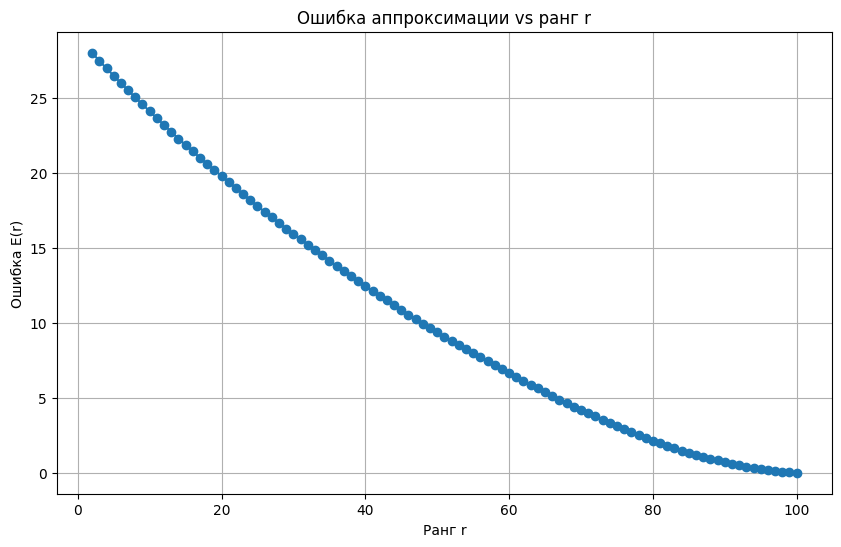

In [4]:
# Шаг 1. Создаём матрицу
n = 100
A = np.random.rand(n, n)

# Шаг 2. SVD-разложение
U, S, Vt = np.linalg.svd(A)

# Функция для аппроксимации
def approximate_matrix(U, S, Vt, r):
    # Берём только первые r столбцов из U
    U_r = U[:, :r]
    # Берём первые r чисел из S (диагональ)
    S_r = np.diag(S[:r])
    # Берём первые r строк из Vt
    Vt_r = Vt[:r, :]
    # Собираем матрицу: U_r × S_r × Vt_r
    A_approx = U_r @ S_r @ Vt_r
    return A_approx

# Функция для ошибки
def compute_error(A, A_approx):
    # Разница между исходной и приближённой матрицей
    diff = A - A_approx
    # Считаем сумму квадратов всех элементов
    error = np.sqrt(np.sum(diff ** 2))
    return error


# Шаг 3–4. Перебираем r и считаем ошибки
r_values = range(2, n + 1)
errors = []
for r in r_values:
    A_approx = approximate_matrix(U, S, Vt, r)
    error = compute_error(A, A_approx)
    errors.append(error)

# Шаг 5. График
plt.figure(figsize=(10, 6))
plt.plot(r_values, errors, marker='o', linestyle='-')
plt.title('Ошибка аппроксимации vs ранг r')
plt.xlabel('Ранг r')
plt.ylabel('Ошибка E(r)')
plt.grid(True)
plt.show()



---

# 2. Начала мат.анализа и оптимизации

## Задача 1: вычисление градиента и критических точек функции

Дана функция:  
$$
f(\mathbf{x}) = x_1^3 - 2x_1x_2 + x_2^2 - 3x_1 - 2x_2, \quad \mathbf{x} \in \mathbb{R}^2.
$$

### Шаг 1. Вычисление градиента ∇f(x)

Градиент функции $f(\mathbf{x})$ — это вектор частных производных:  
$$
\nabla f(\mathbf{x}) = 
\begin{pmatrix}
\dfrac{\partial f}{\partial x_1} \\
\dfrac{\partial f}{\partial x_2}
\end{pmatrix}.
$$

Вычислим частные производные:

1. По переменной $x_1$:  
   $$
   \dfrac{\partial f}{\partial x_1} = 3x_1^2 - 2x_2 - 3.
   $$

2. По переменной $x_2$:  
   $$
   \dfrac{\partial f}{\partial x_2} = -2x_1 + 2x_2 - 2.
   $$

Таким образом, градиент:  
$$
\nabla f(\mathbf{x}) =
\begin{pmatrix}
3x_1^2 - 2x_2 - 3 \\
-2x_1 + 2x_2 - 2
\end{pmatrix}.
$$

### Шаг 2. Нахождение критических точек

Критические точки $\mathbf{x}_c$ удовлетворяют условию:  
$$
\nabla f(\mathbf{x}_c) = \mathbf{0},
$$  
то есть системе уравнений:  
$$
\begin{cases}
3x_1^2 - 2x_2 - 3 = 0, \\
-2x_1 + 2x_2 - 2 = 0.
\end{cases}
$$

#### Решение системы

1. Из второго уравнения выразим $x_2$:  
   $$
   -2x_1 + 2x_2 - 2 = 0 \quad \Rightarrow \quad x_2 = x_1 + 1.
   $$

2. Подставим $x_2 = x_1 + 1$ в первое уравнение:  
   $$
   3x_1^2 - 2(x_1 + 1) - 3 = 0 \quad \Rightarrow \quad 3x_1^2 - 2x_1 - 5 = 0.
   $$

3. Решим квадратное уравнение:  
   $$
   3x_1^2 - 2x_1 - 5 = 0.
   $$  
   Дискриминант:  
   $$
   D = (-2)^2 - 4 \cdot 3 \cdot (-5) = 4 + 60 = 64.
   $$  
   Корни:  
   $$
   x_1 = \dfrac{2 \pm \sqrt{64}}{6} = \dfrac{2 \pm 8}{6}.
   $$  
   Получаем:  
   $$
   x_1^{(1)} = \dfrac{10}{6} = \dfrac{5}{3}, \quad x_1^{(2)} = \dfrac{-6}{6} = -1.
   $$

4. Найдём соответствующие $x_2$:  
   - Для $x_1 = \dfrac{5}{3}$:  
     $$
     x_2 = \dfrac{5}{3} + 1 = \dfrac{8}{3}.
     $$  
   - Для $x_1 = -1$:  
     $$
     x_2 = -1 + 1 = 0.
     $$

### Ответ: критические точки

Функция $f(\mathbf{x})$ имеет две критические точки:  
1. $\mathbf{x}_c^{(1)} = \left( \dfrac{5}{3},\ \dfrac{8}{3} \right)$,  
2. $\mathbf{x}_c^{(2)} = \left( -1,\ 0 \right)$.


In [14]:
# 1. Определяем переменные
x1, x2 = symbols('x1 x2')

# 2. Задаем функцию f(x)
f = x1**3 - 2*x1*x2 + x2**2 - 3*x1 - 2*x2

print("Исходная функция f(x):")
display(f)

# 3. Вычисляем частные производные (компоненты градиента)
df_dx1 = f.diff(x1)  # ∂f/∂x1
df_dx2 = f.diff(x2)  # ∂f/∂x2

print("\nЧастные производные:")
display(df_dx1)
display(df_dx2)

# 4. Формируем градиент как матрицу-столбец (вектор)
gradient = Matrix([df_dx1, df_dx2])
print("\nГрадиент ∇f(x):")
display(gradient)

# 5. Находим критические точки: решаем систему ∇f(x) = 0
# Записываем уравнения системы
eq1 = Eq(df_dx1, 0)
eq2 = Eq(df_dx2, 0)

# Решаем систему уравнений
critical_points = solve((eq1, eq2), (x1, x2))

print("\nКритические точки (где ∇f(x) = 0):")
if critical_points:
    # Проверяем тип первого элемента, чтобы понять структуру
    if isinstance(critical_points[0], dict):
        # Случай: список словарей или один словарь
        if isinstance(critical_points, dict):
            points = [critical_points]
        else:
            points = critical_points
        for i, point in enumerate(points, 1):
            print(f"Точка {i}: x1 = {point[x1]}, x2 = {point[x2]}")
            print(f"xc_{i} = ({point[x1]}, {point[x2]})")
    else:
        # Случай: список кортежей (наиболее вероятный для вашего примера)
        for i, (val_x1, val_x2) in enumerate(critical_points, 1):
            print(f"Точка {i}: x1 = {val_x1}, x2 = {val_x2}")
            print(f"xc_{i} = ({val_x1}, {val_x2})")
else:
    print("Критических точек не найдено")


# 6. Дополнительно: выводим градиент в упрощённом виде (если нужно)
print("\nУпрощённый градиент (если возможно):")
simplified_gradient = Matrix([simplify(df_dx1), simplify(df_dx2)])
display(simplified_gradient)


Исходная функция f(x):


x1**3 - 2*x1*x2 - 3*x1 + x2**2 - 2*x2


Частные производные:


3*x1**2 - 2*x2 - 3

-2*x1 + 2*x2 - 2


Градиент ∇f(x):


Matrix([
[3*x1**2 - 2*x2 - 3],
[  -2*x1 + 2*x2 - 2]])


Критические точки (где ∇f(x) = 0):
Точка 1: x1 = -1, x2 = 0
xc_1 = (-1, 0)
Точка 2: x1 = 5/3, x2 = 8/3
xc_2 = (5/3, 8/3)

Упрощённый градиент (если возможно):


Matrix([
[3*x1**2 - 2*x2 - 3],
[  -2*x1 + 2*x2 - 2]])

---

## Задача 2:

### Проверка выполнения уравнения для функции $f(x_1, x_2) = \ln(\sqrt{x_1} + \sqrt{x_2})$


Требуется проверить, удовлетворяет ли функция уравнению:  
$$
x_1 \frac{\partial f}{\partial x_1} + x_2 \frac{\partial f}{\partial x_2} = \frac{1}{2}.
$$

#### Шаг 1. Нахождение частных производных

##### Производная по $x_1$

$$\frac{\partial f}{\partial x_1} = \frac{\partial\ln(\sqrt{x_1} + \sqrt{x_2})}{\partial x_1} $$


Используем правило дифференцирования логарифма $(\ln u)' = \dfrac{u'}{u}$, где $u = \sqrt{x_1} + \sqrt{x_2}$:

$$
\frac{\partial u}{\partial x_1} = \frac{1}{2\sqrt{x_1}}.
$$

Тогда:  
$$
\frac{\partial f}{\partial x_1} = \frac{\dfrac{1}{2\sqrt{x_1}}}{\sqrt{x_1} + \sqrt{x_2}} = \frac{1}{2\sqrt{x_1} (\sqrt{x_1} + \sqrt{x_2})}.
$$

##### Производная по $x_2$

Аналогично:  
$$
\frac{\partial u}{\partial x_2} = \frac{1}{2\sqrt{x_2}},
$$  
$$
\frac{\partial f}{\partial x_2} = \frac{\dfrac{1}{2\sqrt{x_2}}}{\sqrt{x_1} + \sqrt{x_2}} = \frac{1}{2\sqrt{x_2} (\sqrt{x_1} + \sqrt{x_2})}.
$$

#### Шаг 2. Подстановка в левую часть уравнения

Вычисляем:  
$$
x_1 \frac{\partial f}{\partial x_1} + x_2 \frac{\partial f}{\partial x_2}.
$$

Подставляем найденные производные:  
$$
x_1 \cdot \frac{1}{2\sqrt{x_1} (\sqrt{x_1} + \sqrt{x_2})} + x_2 \cdot \frac{1}{2\sqrt{x_2} (\sqrt{x_1} + \sqrt{x_2})}.
$$

##### Упрощение первого слагаемого

$$
\frac{x_1}{2\sqrt{x_1} (\sqrt{x_1} + \sqrt{x_2})} = \frac{\sqrt{x_1}}{2 (\sqrt{x_1} + \sqrt{x_2})},
$$  
так как $\dfrac{x_1}{\sqrt{x_1}} = \sqrt{x_1}$.


##### Упрощение второго слагаемого

$$
\frac{x_2}{2\sqrt{x_2} (\sqrt{x_1} + \sqrt{x_2})} = \frac{\sqrt{x_2}}{2 (\sqrt{x_1} + \sqrt{x_2})}.
$$

##### Сумма слагаемых

$$
\frac{\sqrt{x_1}}{2 (\sqrt{x_1} + \sqrt{x_2})} + \frac{\sqrt{x_2}}{2 (\sqrt{x_1} + \sqrt{x_2})} = \frac{\sqrt{x_1} + \sqrt{x_2}}{2 (\sqrt{x_1} + \sqrt{x_2})}.
$$

##### Финальное упрощение

Сокращаем числитель и знаменатель:  
$$
\frac{\sqrt{x_1} + \sqrt{x_2}}{2 (\sqrt{x_1} + \sqrt{x_2})} = \frac{1}{2}.
$$

### Вывод

Левая часть уравнения равна $\dfrac{1}{2}$, что совпадает с правой частью.


**Ответ:** функция $f(x_1, x_2) = \ln(\sqrt{x_1} + \sqrt{x_2})$ **удовлетворяет** заданному уравнению.


---

## Задание 3:

### Нахождение матрицы Якоби и её значения в точке

Дана вектор‑функция $f : \mathbb{R}^3 \to \mathbb{R}^2$:
$$
f(x, y, z) = \begin{pmatrix} x + y + z \\ xyz \end{pmatrix}.
$$

Требуется найти:
1. Матрицу Якоби $J_f(x, y, z)$.
2. Значение $J_f$ в точке $v = (1, 2, 3)^\top$.


#### Шаг 1. Определение матрицы Якоби

Матрица Якоби $J_f$ для $f : \mathbb{R}^n \to \mathbb{R}^m$ — это матрица размера $m \times n$, составленная из частных производных компонент $f_i$ по переменным $x_j$:
$$
J_f = \begin{pmatrix}
\frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial y} & \frac{\partial f_1}{\partial z} \\
\frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial y} & \frac{\partial f_2}{\partial z}
\end{pmatrix}.
$$

В нашем случае:
- $f_1(x, y, z) = x + y + z$,
- $f_2(x, y, z) = xyz$.


#### Шаг 2. Вычисление частных производных


**Для $f_1 = x + y + z$:**
- $\dfrac{\partial f_1}{\partial x} = 1$,
- $\dfrac{\partial f_1}{\partial y} = 1$,
- $\dfrac{\partial f_1}{\partial z} = 1$.

**Для $f_2 = xyz$:**
- $\dfrac{\partial f_2}{\partial x} = yz$,
- $\dfrac{\partial f_2}{\partial y} = xz$,
- $\dfrac{\partial f_2}{\partial z} = xy$.


#### Шаг 3. Общая матрица Якоби

Подставляем найденные производные:
$$
J_f(x, y, z) = \begin{pmatrix}
1 & 1 & 1 \\
yz & xz & xy
\end{pmatrix}.
$$

#### Шаг 4. Значение в точке $v = (1, 2, 3)^\top$

Подставляем $x = 1$, $y = 2$, $z = 3$ во вторую строку:
- $yz = 2 \cdot 3 = 6$,
- $xz = 1 \cdot 3 = 3$,
- $xy = 1 \cdot 2 = 2$.

Получаем:
$$
J_f(1, 2, 3) = \begin{pmatrix}
1 & 1 & 1 \\
6 & 3 & 2
\end{pmatrix}.
$$

### Ответ

1. **Общая матрица Якоби:**
   $$
   J_f(x, y, z) = \begin{pmatrix}
   1 & 1 & 1 \\
   yz & xz & xy
   \end{pmatrix}.
   $$

2. **Значение в точке $v = (1, 2, 3)^\top$:**
   $$
   J_f(1, 2, 3) = \begin{pmatrix}
   1 & 1 & 1 \\
   6 & 3 & 2
   \end{pmatrix}.
   $$


In [ ]:
# Определяем переменные
x, y, z = symbols('x y z')

# Задаем функцию f: R^3 -> R^2
f1 = x + y + z      # первая компонента
f2 = x * y * z     # вторая компонента


# Собираем вектор-функцию
f = Matrix([f1, f2])


# Вычисляем матрицу Якоби (частные производные по x, y, z)
J = f.jacobian([x, y, z])


print("Матрица Якоби J_f(x, y, z):")
display(J)

# Подставляем точку v = (1, 2, 3)
v = {x: 1, y: 2, z: 3}
J_at_v = J.subs(v)


print("Значение матрицы Якоби в точке v = (1, 2, 3):")
display(J_at_v)


Матрица Якоби J_f(x, y, z):


Matrix([
[  1,   1,   1],
[y*z, x*z, x*y]])

Значение матрицы Якоби в точке v = (1, 2, 3):


Matrix([
[1, 1, 1],
[6, 3, 2]])

---

## Задание 4:

### Нахождение первого дифференциала $df(\mathbf{x})$ и градиента $\nabla f(\mathbf{x})$

Дана функция:  
$$
f(\mathbf{x}) = \frac{1}{3} \|\mathbf{x}\|_2^3, \quad \mathbf{x} \in \mathbb{R}^n \setminus \{\mathbf{0}\},
$$  
где $\|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}$ — евклидова норма вектора $\mathbf{x} = (x_1, \ldots, x_n)$.


#### Шаг 1. Перепишем функцию в явном виде


$$
f(\mathbf{x}) = \frac{1}{3} \left( x_1^2 + x_2^2 + \cdots + x_n^2 \right)^{3/2}.
$$

#### Шаг 2. Найдём частные производные


Обозначим $r = \|\mathbf{x}\|_2 = \sqrt{\sum_{j=1}^n x_j^2}$. Тогда $f = \dfrac{1}{3} r^3$.


По правилу цепочки:  
$$
\frac{\partial f}{\partial x_i} = \frac{d}{dr}\left(\frac{1}{3}r^3\right) \cdot \frac{\partial r}{\partial x_i} = r^2 \cdot \frac{\partial r}{\partial x_i}.
$$

Находим $\dfrac{\partial r}{\partial x_i}$:  
$$
r = \left( \sum_{j=1}^n x_j^2 \right)^{1/2} \quad \Rightarrow \quad \frac{\partial r}{\partial x_i} = \frac{1}{2} \left( \sum_{j=1}^n x_j^2 \right)^{-1/2} \cdot 2x_i = \frac{x_i}{r}.
$$

Подставляем:  
$$
\frac{\partial f}{\partial x_i} = r^2 \cdot \frac{x_i}{r} = r \cdot x_i = \|\mathbf{x}\|_2 \cdot x_i.
$$

#### Шаг 3. Запишем градиент $\nabla f(\mathbf{x})$


Градиент — вектор всех частных производных:  
$$
\nabla f(\mathbf{x}) =
\begin{pmatrix}
\dfrac{\partial f}{\partial x_1} \\
\dfrac{\partial f}{\partial x_2} \\
\vdots \\
\dfrac{\partial f}{\partial x_n}
\end{pmatrix}
=
\begin{pmatrix}
\|\mathbf{x}\|_2 \cdot x_1 \\
\|\mathbf{x}\|_2 \cdot x_2 \\
\vdots \\
\|\mathbf{x}\|_2 \cdot x_n
\end{pmatrix}
= \|\mathbf{x}\|_2 \cdot \mathbf{x}.
$$

**Ответ для градиента:**  
$$
\boxed{\nabla f(\mathbf{x}) = \|\mathbf{x}\|_2 \cdot \mathbf{x}}
$$

#### Шаг 4. Найдём первый дифференциал $df(\mathbf{x})$


Дифференциал скалярной функции:  
$$
df(\mathbf{x}) = \sum_{i=1}^n \frac{\partial f}{\partial x_i} \, dx_i.
$$

Подставляем частные производные:  
$$
df(\mathbf{x}) = \sum_{i=1}^n \|\mathbf{x}\|_2 \cdot x_i \, dx_i = \|\mathbf{x}\|_2 \sum_{i=1}^n x_i \, dx_i.
$$

Заметим, что $\sum_{i=1}^n x_i \, dx_i$ — это скалярное произведение $\mathbf{x} \cdot d\mathbf{x}$, где $d\mathbf{x} = (dx_1, \ldots, dx_n)$.


**Ответ для дифференциала:**  
$$
\boxed{df(\mathbf{x}) = \|\mathbf{x}\|_2 \cdot (\mathbf{x} \cdot d\mathbf{x})}
$$


### Итоговые ответы


- **Градиент:** $\nabla f(\mathbf{x}) = \|\mathbf{x}\|_2 \cdot \mathbf{x}$;  
- **Первый дифференциал:** $df(\mathbf{x}) = \|\mathbf{x}\|_2 \cdot (\mathbf{x} \cdot d\mathbf{x})$.


### Важные замечания

1. Формулы справедливы **только при $\mathbf{x} \ne \mathbf{0}$**, так как в нуле норма $\|\mathbf{x}\|_2$ не дифференцируема.
2. Результат имеет ясную интерпретацию: функция $f$ растёт пропорционально длине вектора $\mathbf{x}$ и его компонентам.


---

## Задание 5:

### Нахождение градиента и первого дифференциала функции $f(\mathbf{x}) = \|\mathbf{x}\|_2$

**Дано:**  
$$
f(\mathbf{x}) = \|\mathbf{x}\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}, \quad \mathbf{x} \in \mathbb{R}^n \setminus \{\mathbf{0}\}.
$$

**Требуется найти:**  
1. Градиент $\nabla f(\mathbf{x})$;  
2. Первый дифференциал $df(\mathbf{x})$.


#### 1. Вычисление частных производных


Частная производная по $x_i$:  
$$
\frac{\partial f}{\partial x_i} = \frac{\partial}{\partial x_i} \left( \sqrt{\sum_{j=1}^n x_j^2} \right).
$$

По правилу дифференцирования сложной функции:  
$$
\frac{\partial f}{\partial x_i} = \frac{1}{2\sqrt{\sum_{j=1}^n x_j^2}} \cdot 2x_i = \frac{x_i}{\|\mathbf{x}\|_2}.
$$

**Итог:**  
$$
\frac{\partial f}{\partial x_i} = \frac{x_i}{\|\mathbf{x}\|_2}.
$$


#### 2. Градиент $\nabla f(\mathbf{x})$


Градиент — вектор всех частных производных:  
$$
\nabla f(\mathbf{x}) = 
\begin{pmatrix}
\dfrac{\partial f}{\partial x_1} \\
\dfrac{\partial f}{\partial x_2} \\
\vdots \\
\dfrac{\partial f}{\partial x_n}
\end{pmatrix}
=
\begin{pmatrix}
\dfrac{x_1}{\|\mathbf{x}\|_2} \\
\dfrac{x_2}{\|\mathbf{x}\|_2} \\
\vdots \\
\dfrac{x_n}{\|\mathbf{x}\|_2}
\end{pmatrix}
= \frac{\mathbf{x}}{\|\mathbf{x}\|_2}.
$$

**Ответ для градиента:**  
$$
\boxed{\nabla f(\mathbf{x}) = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}}
$$

*Пояснение:* градиент направлен вдоль вектора $\mathbf{x}$ и имеет единичную длину (так как $\left\| \dfrac{\mathbf{x}}{\|\mathbf{x}\|_2} \right\|_2 = 1$).


#### 3. Первый дифференциал $df(\mathbf{x})$


Дифференциал скалярной функции:  
$$
df(\mathbf{x}) = \sum_{i=1}^n \frac{\partial f}{\partial x_i} \, dx_i.
$$

Подставляем частные производные:  
$$
df(\mathbf{x}) = \sum_{i=1}^n \frac{x_i}{\|\mathbf{x}\|_2} \, dx_i = \frac{1}{\|\mathbf{x}\|_2} \sum_{i=1}^n x_i \, dx_i.
$$

Заметим, что $\sum_{i=1}^n x_i \, dx_i$ — это скалярное произведение $\mathbf{x} \cdot d\mathbf{x}$, где $d\mathbf{x} = (dx_1, \ldots, dx_n)$.


**Ответ для дифференциала:**  
$$
\boxed{df(\mathbf{x}) = \frac{\langle \mathbf{x}, d\mathbf{x} \rangle}{\|\mathbf{x}\|_2}}
$$

*Пояснение:* дифференциал показывает, как линейно изменяется $f(\mathbf{x})$ при малом приращении $d\mathbf{x}$.


#### 4. Итоговые формулы


- **Градиент:**  
  $$
  \nabla f(\mathbf{x}) = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}.
  $$

- **Первый дифференциал:**  
  $$
  df(\mathbf{x}) = \frac{\langle \mathbf{x}, d\mathbf{x} \rangle}{\|\mathbf{x}\|_2}.
  $$


---

## Задание 6:

### Нахождение градиента и первого дифференциала функции $f(\mathbf{x}) = \|A\mathbf{x}\|_2$


**Дано:**  
$$
f(\mathbf{x}) = \|A\mathbf{x}\|_2 = \sqrt{(A\mathbf{x})^\top (A\mathbf{x})} = \sqrt{\mathbf{x}^\top A^\top A \mathbf{x}}, \\
\mathbf{x} \in \mathbb{R}^n \setminus \{\mathbf{0}\}, \quad A \in \mathbb{R}^{m \times n}.
$$

**Требуется найти:**  
1. Градиент $\nabla f(\mathbf{x})$;  
2. Первый дифференциал $df(\mathbf{x})$.


#### 1. Вычисление градиента $\nabla f(\mathbf{x})$


Функция: $f(\mathbf{x}) = (\mathbf{x}^\top A^\top A \mathbf{x})^{1/2}$.


По правилу дифференцирования сложной функции:  
$$
\nabla f(\mathbf{x}) = \frac{1}{2} (\mathbf{x}^\top A^\top A \mathbf{x})^{-1/2} \cdot \nabla (\mathbf{x}^\top A^\top A \mathbf{x}).
$$

Для квадратичной формы известно:  
$$
\nabla (\mathbf{x}^\top B \mathbf{x}) = 2B\mathbf{x}, \quad \text{где } B = A^\top A.
$$

Подставляем:  
$$
\nabla (\mathbf{x}^\top A^\top A \mathbf{x}) = 2A^\top A \mathbf{x}.
$$

Тогда градиент:  
$$
\nabla f(\mathbf{x}) = \frac{1}{2} (\mathbf{x}^\top A^\top A \mathbf{x})^{-1/2} \cdot 2A^\top A \mathbf{x} = \frac{A^\top A \mathbf{x}}{\|A\mathbf{x}\|_2}.
$$


**Ответ:**  
$$
\boxed{\nabla f(\mathbf{x}) = \frac{A^\top A \mathbf{x}}{\|A\mathbf{x}\|_2}}
$$


#### 2. Вычисление первого дифференциала $df(\mathbf{x})$


Дифференциал скалярной функции:  
$$
df(\mathbf{x}) = \nabla f(\mathbf{x})^\top d\mathbf{x}.
$$

Подставляем градиент:  
$$
df(\mathbf{x}) = \left( \frac{A^\top A \mathbf{x}}{\|A\mathbf{x}\|_2} \right)^\top d\mathbf{x} = \frac{(A^\top A \mathbf{x})^\top d\mathbf{x}}{\|A\mathbf{x}\|_2}.
$$

Учитывая $(A^\top A \mathbf{x})^\top = \mathbf{x}^\top A^\top A$, получаем:  
$$
df(\mathbf{x}) = \frac{\mathbf{x}^\top A^\top A \, d\mathbf{x}}{\|A\mathbf{x}\|_2}.
$$


Или через скалярное произведение:  
$$
df(\mathbf{x}) = \frac{\langle A^\top A \mathbf{x}, d\mathbf{x} \rangle}{\|A\mathbf{x}\|_2}.
$$


**Ответ:**  
$$
\boxed{df(\mathbf{x}) = \frac{\langle A^\top A \mathbf{x}, d\mathbf{x} \rangle}{\|A\mathbf{x}\|_2}}
$$


#### 3. Итоговые формулы


- **Градиент:**  
  $$
  \nabla f(\mathbf{x}) = \frac{A^\top A \mathbf{x}}{\|A\mathbf{x}\|_2}.
  $$


- **Первый дифференциал:**  
  $$
  df(\mathbf{x}) = \frac{\langle A^\top A \mathbf{x}, d\mathbf{x} \rangle}{\|A\mathbf{x}\|_2}.
  $$


#### 4. Пример вычисления ($n=2$, $m=3$)


**Дано:**  
- $A = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{pmatrix}$;  
- $\mathbf{x} = (2, 1)$;  
- $d\mathbf{x} = (0{,}1; -0{,}2)$.

**Шаг 1.** Вычисляем $A\mathbf{x}$:  
$$
A\mathbf{x} = \begin{pmatrix} 1\cdot2 + 0\cdot1 \\ 0\cdot2 + 1\cdot1 \\ 1\cdot2 + 1\cdot1 \end{pmatrix} = \begin{pmatrix} 2 \\ 1 \\ 3 \end{pmatrix}.
$$


**Шаг 2.** Норма $\|A\mathbf{x}\|_2$:  
$$
\|A\mathbf{x}\|_2 = \sqrt{2^2 + 1^2 + 3^2} = \sqrt{14} \approx 3{,}7417.
$$

**Шаг 3.** Матрица $A^\top A$:  
$$
A^\top A = \begin{pmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{pmatrix} = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}.
$$

**Шаг 4.** Вектор $A^\top A \mathbf{x}$:  
$$
A^\top A \mathbf{x} = \begin{pmatrix} 2\cdot2 + 1\cdot1 \\ 1\cdot2 + 2\cdot1 \end{pmatrix} = \begin{pmatrix} 5 \\ 4 \end{pmatrix}.
$$

**Шаг 5.** Градиент:  
$$
\nabla f(\mathbf{x}) = \frac{1}{\sqrt{14}} \begin{pmatrix} 5 \\ 4 \end{pmatrix} \approx \begin{pmatrix} 1{,}3363 \\ 1{,}0690 \end{pmatrix}.
$$

**Шаг 6.** Дифференциал:  
$$
df(\mathbf{x}) = \frac{5 \cdot 0{,}1 + 4 \cdot (-0{,}2)}{\sqrt{14}} = \frac{-0{,}3}{\sqrt{14}} \approx -0{,}0802.
$$



---

## Задание 7:

### Нахождение градиента и первого дифференциала функции $f(\mathbf{x}) = -e^{-\mathbf{x}^\top \mathbf{x}}$


**Дано:**  
$$
f(\mathbf{x}) = -e^{-\mathbf{x}^\top \mathbf{x}} = -e^{-\|\mathbf{x}\|_2^2}, \quad \mathbf{x} \in \mathbb{R}^n.
$$

**Требуется найти:**  
1. Градиент $\nabla f(\mathbf{x})$;  
2. Первый дифференциал $df(\mathbf{x})$.


#### 1. Вычисление градиента $\nabla f(\mathbf{x})$


Функция представляет собой композицию:  
- внутренней функции $g(\mathbf{x}) = \mathbf{x}^\top \mathbf{x} = \|\mathbf{x}\|_2^2$;  
- внешней функции $h(g) = -e^{-g}$.

По правилу:  
$$
\nabla f(\mathbf{x}) = h'(g(\mathbf{x})) \cdot \nabla g(\mathbf{x}).
$$

**Шаг 1.** Находим производную внешней функции:  
$$
h'(g) = \frac{d}{dg} \left( -e^{-g} \right) = e^{-g}.
$$

**Шаг 2.** Находим градиент внутренней функции:  
$$
g(\mathbf{x}) = \sum_{i=1}^n x_i^2 \quad \Rightarrow \quad \frac{\partial g}{\partial x_i} = 2x_i.
$$  
Следовательно:  
$$
\nabla g(\mathbf{x}) = 2\mathbf{x}.
$$

**Шаг 3.** Подставляем в цепное правило:  
$$
\nabla f(\mathbf{x}) = e^{-\mathbf{x}^\top \mathbf{x}} \cdot 2\mathbf{x} = 2\mathbf{x} e^{-\|\mathbf{x}\|_2^2}.
$$

**Ответ для градиента:**  
$$
\boxed{\nabla f(\mathbf{x}) = 2\mathbf{x} e^{-\|\mathbf{x}\|_2^2}}
$$


#### 2. Вычисление первого дифференциала $df(\mathbf{x})$


Дифференциал скалярной функции:  
$$
df(\mathbf{x}) = \nabla f(\mathbf{x})^\top d\mathbf{x}.
$$

Подставляем найденный градиент:  
$$
df(\mathbf{x}) = \left( 2\mathbf{x} e^{-\|\mathbf{x}\|_2^2} \right)^\top d\mathbf{x} = 2 e^{-\|\mathbf{x}\|_2^2} \cdot \mathbf{x}^\top d\mathbf{x}.
$$


Через скалярное произведение:  
$$
df(\mathbf{x}) = 2 e^{-\|\mathbf{x}\|_2^2} \langle \mathbf{x}, d\mathbf{x} \rangle.
$$

**Ответ для дифференциала:**  
$$
\boxed{df(\mathbf{x}) = 2 e^{-\|\mathbf{x}\|_2^2} \langle \mathbf{x}, d\mathbf{x} \rangle}
$$


#### 3. Итоговые формулы


- **Градиент:**  
  $$
  \nabla f(\mathbf{x}) = 2\mathbf{x} e^{-\|\mathbf{x}\|_2^2}.
  $$

- **Первый дифференциал:**  
  $$
  df(\mathbf{x}) = 2 e^{-\|\mathbf{x}\|_2^2} \langle \mathbf{x}, d\mathbf{x} \rangle.
  $$


#### 4. Пример вычисления (для $n=2$)


Пусть $\mathbf{x} = (1, 2)$, $d\mathbf{x} = (0{,}01; -0{,}02)$.


**Шаг 1.** Вычисляем $\|\mathbf{x}\|_2^2$:  
$$
\|\mathbf{x}\|_2^2 = 1^2 + 2^2 = 5.
$$

**Шаг 2.** Находим экспоненту:  
$$
e^{-\|\mathbf{x}\|_2^2} = e^{-5} \approx 0{,}006738.
$$

**Шаг 3.** Градиент:  
$$
\nabla f(\mathbf{x}) = 2 \begin{pmatrix} 1 \\ 2 \end{pmatrix} \cdot e^{-5} \approx \begin{pmatrix} 0{,}013476 \\ 0{,}026952 \end{pmatrix}.
$$

**Шаг 4.** Дифференциал:  
$$
df(\mathbf{x}) = 2 e^{-5} \cdot (1 \cdot 0{,}01 + 2 \cdot (-0{,}02)) = 2 \cdot 0{,}006738 \cdot (-0{,}03) \approx -0{,}0004043.
$$
